# Получение оригинальной матрицы изображения

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image_path = r"picture1.png"  #никакой кириллицы тут в пути!!!
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img is None:
    raise ValueError('Изображение не грузанулось')

img = cv2.resize(img, (256, 256))
imgf = img.astype(np.float64)
print(imgf)

[[ 58.  61.  61. ... 124. 124. 124.]
 [ 58.  60.  61. ... 124. 125. 124.]
 [ 60.  60.  61. ... 125. 125. 124.]
 ...
 [ 97.  96.  94. ...  68.  71.  87.]
 [170. 170. 169. ...  68.  72.  85.]
 [216. 217. 216. ...  67.  72.  75.]]


## Пример

In [62]:
# Пример изображения: 4x4 (мелкая матрица)
imgex = np.array([
    [52, 55, 61, 59],
    [62, 59, 55, 90],
    [63, 65, 66, 80],
    [58, 55, 52, 85]
], dtype=int)

# Вывод картинки

Оригинальное изображение


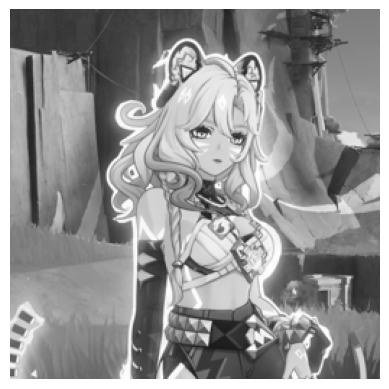

In [61]:
def show_matrix_as_image(matrix):
    plt.imshow(matrix, cmap='gray', vmin=0, vmax=255)
    plt.axis('off')
    plt.show()
print("Оригинальное изображение")
show_matrix_as_image(img)

# Преобразование 9/7

Коэффициенты:
$$
\begin{aligned}
\alpha &= -1.586134342, \\
\beta &= -0.05298011854, \\
\gamma &= 0.8829110762, \\
\delta &= 0.4435068522, \\
\zeta &= 1.149604398.
\end{aligned}
$$

Преобразования описываются следующим образом:
$$
\begin{aligned}
s_l^{(0)} &= x_{2l} \\
d_l^{(0)} &= x_{2l+1} \\
d_l^{(1)} &= d_l^{(0)} + \alpha \left( s_l^{(0)} + s_{l+1}^{(0)} \right) \\
s_l^{(1)} &= s_l^{(0)} + \beta \left( d_l^{(1)} + d_{l-1}^{(1)} \right) \\
d_l^{(2)} &= d_l^{(1)} + \gamma \left( s_l^{(1)} + s_{l+1}^{(1)} \right) \\
s_l^{(2)} &= s_l^{(1)} + \delta \left( d_l^{(2)} + d_{l-1}^{(2)} \right) \\
s_l &= \zeta \, s_l^{(2)} \\
d_l &= \frac{d_l^{(2)}}{\zeta}
\end{aligned}
$$

где $ x_{i} $ - элементы исходной матрицы, $ s_l^{(0)} $ - отобранные элементы с чётными индексами, $ d_l^{(0)} $ - отобранные элементы с не чётными индексами, $ s_l^{(1)} $ и $ d_l^{(1)} $ - после первого преобразования, $ s_l^{(2)} $ и $ d_l^{(2)} $ - после второго преобразования

In [6]:
alpha = -1.586134342
beta = -0.05298011854
gamma = 0.8829110762
delta = 0.4435068522
zeta = 1.149604398

In [53]:
def wavelet97_1d(X):
    #N = len(X)

    # Чётные не чётные
    S0 = X[::2].copy()
    D0 = X[1::2].copy()
    
    # 1-е преобразование
    D1 = list()
    S1 = list()
    for l in range(len(D0) - 1):
        D1.append(D0[l] + alpha * (S0[l] + S0[l + 1]))
    D1.append(D0[l] + alpha * (S0[l] + S0[l]))

    for l in range(len(S0)):
        S1.append(S0[l] + beta * (D1[l] + D1[l - 1]))

    # 2-е преобразование
    D2 = list()
    S2 = list()
    for l in range(len(D0) - 1):
        D2.append(D1[l] + gamma * (S1[l] + S1[l + 1]))
    D2.append(D1[l] + gamma * (S1[l] + S1[l]))

    for l in range(len(S0)):
        S2.append(S1[l] + delta * (D2[l] + D2[l - 1]))
    
    S2 = np.array(S2)
    D2 = np.array(D2)
    S = zeta * S2
    D = D2 / zeta

    return np.concatenate([S, D])
    

In [31]:
def wavelet97_2d(matrix):
    h, w = matrix.shape
    temp = matrix.copy()

    # Применяем по строкам
    for i in range(h):
        temp[i, :] = wavelet97_1d(temp[i, :])

    # Применяем по столбцам
    for j in range(w):
        temp[:, j] = wavelet97_1d(temp[:, j])

    return temp

## Пример

In [43]:
preobr_imgex = wavelet97_2d(imgex)
print(preobr_imgex)

[[  65   41 -152 -136]
 [  56   24 -128 -107]
 [-151 -148  344  342]
 [-145 -137  328  322]]


# Обратное преобразование

In [51]:
def wavelet97_1d_back(signal):
    N = len(signal)
    N1 = N // 2
    D = np.array(signal[N1:])
    S = np.array(signal[:N1])

    S2 = S / zeta
    D2 = D * zeta

    S1 = list()
    S1.append(S2[0] - delta * (D2[0] + D2[0]))
    for k in range(1, N1):
        S1.append(S2[k] - delta * (D2[k] + D2[k - 1]))

    D1 = list()
    for k in range(N1 - 1):
        D1.append(D2[k] - gamma * (S1[k] + S1[k + 1]))
    D1.append(D2[k] - gamma * (S1[k] + S1[k]))

    S0 = list()
    S0.append(S1[0] - beta * (D1[0] + D1[0]))
    for k in range(1, N1):
        S0.append(S1[k] - beta * (D1[k] + D1[k - 1]))

    D0 = list()
    for k in range(N1 - 1):
        D0.append(D1[k] - alpha * (S0[k] + S0[k + 1]))
    D0.append(D1[k] - alpha * (S0[k] + S0[k]))

    X = np.empty(N, dtype = np.float64)
    X[::2] = S0
    X[1::2] = D0

    return X

def wavelet97_2d_back(M1, M2, M3, M4):  #Матрицу надо склеивать из нескольких кусков
    matrix = np.vstack((np.hstack((M1, M2)), np.hstack((M3, M4))))
    h, w = matrix.shape
    temp = matrix.copy()

    # Применяем по столбцам
    for j in range(w):
        temp[:, j] = wavelet97_1d_back(temp[:, j])
    
    # Применяем по строкам
    for i in range(h):
        temp[i, :] = wavelet97_1d_back(temp[i, :])

    return temp


def wavelet97_2d_back_short(matrix):
    h, w = matrix.shape
    temp = matrix.copy()

    # Применяем по столбцам
    for j in range(w):
        temp[:, j] = wavelet97_1d_back(temp[:, j])
    
    # Применяем по строкам
    for i in range(h):
        temp[i, :] = wavelet97_1d_back(temp[i, :])

    return temp

## Примеры

In [54]:
print(imgex[0])
preobr_imgex0 = wavelet97_1d(imgex[0])
print(preobr_imgex0)

print(wavelet97_1d_back(preobr_imgex0))


[52 55 61 59]
[67.38648458 77.73292416 -2.22235999 -9.13447662]
[48.04920429 52.09763191 61.15923918 31.30335534]


In [55]:
preobr_imgex = wavelet97_2d(imgex)
print(preobr_imgex)

print(wavelet97_2d_back_short(preobr_imgex))
print(imgex)

[[ 93 100  -2  -8]
 [116 116   0   0]
 [  7  -2   1   7]
 [ -8 -13   0   1]]
[[41 46 56 21]
 [60 55 52 67]
 [61 63 64 57]
 [27 30 39 11]]
[[52 55 61 59]
 [62 59 55 90]
 [63 65 66 80]
 [58 55 52 85]]


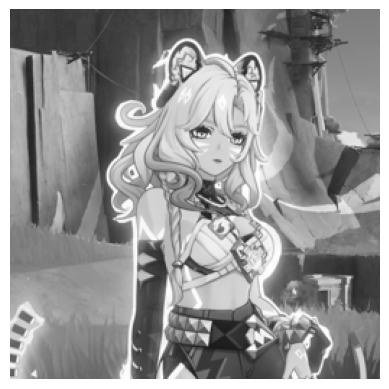

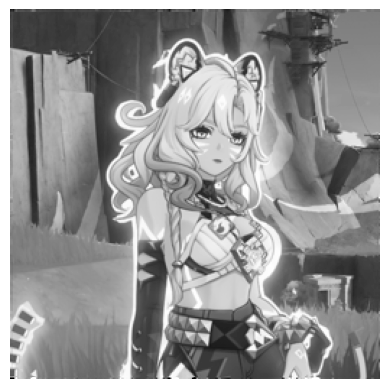

[[ 58.  61.  61. ... 124. 124. 124.]
 [ 58.  60.  61. ... 124. 125. 124.]
 [ 60.  60.  61. ... 125. 125. 124.]
 ...
 [ 97.  96.  94. ...  68.  71.  87.]
 [170. 170. 169. ...  68.  72.  85.]
 [216. 217. 216. ...  67.  72.  75.]]
[[ 26.31530998  37.46622532  21.34332735 ... 119.89636989 118.89593996
  120.46860374]
 [ 47.20203502  55.21361128  44.76723739 ... 114.87858776 115.61024934
  114.05110689]
 [ 66.90275507  72.25392105  63.41636837 ... 124.87637742 124.93931574
  124.74208122]
 ...
 [ 87.11253016  85.78795228  90.00431929 ...  67.72826073  70.70638446
   61.75677949]
 [156.94407261 149.66165395 166.33038651 ...  67.69608002  71.73128771
   60.13320489]
 [-10.5385479   -4.01851535 -18.22505445 ...  67.81239153  67.709451
   66.68710693]]


In [56]:
preobr_img = wavelet97_2d(imgf)
img_back = wavelet97_2d_back_short(preobr_img)

show_matrix_as_image(imgf)
show_matrix_as_image(img_back)

print(imgf)
print(img_back)

# Квантование

In [63]:
def quant(mat, d):
    shir = len(mat[0])     #ширина матрицы
    vi = len(mat)       #высота матрицы
    
    for i in range(vi):
        for j in range(shir):
            mat[i][j] = round(mat[i][j] / d) * d
    return mat

# «Cобранные» программы

## Квантование + сохранение только LL на первых трёх шагах

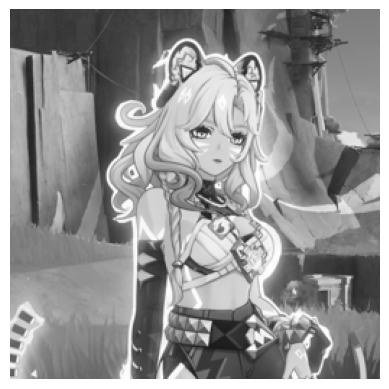

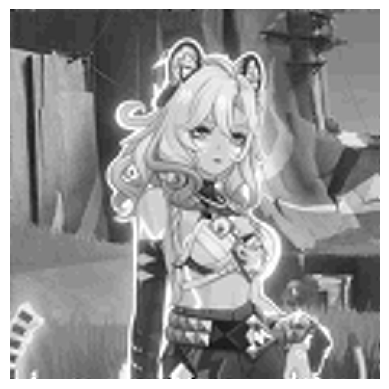

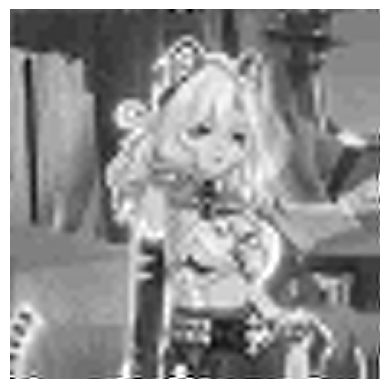

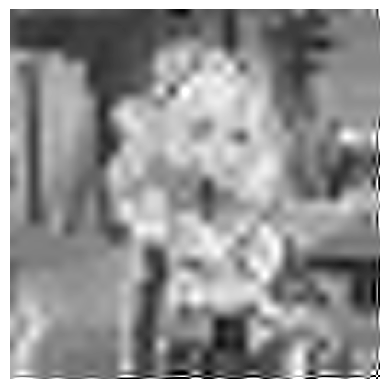

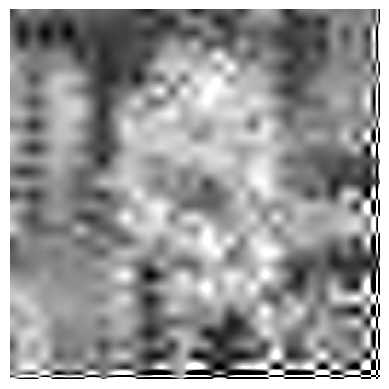

Средняя дисперсия:  49892.17335088008


In [59]:
show_matrix_as_image(img)

loc_res = wavelet97_2d(imgf)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL1 = quant(loc_res[:new_shir, :new_vi], 16)

inv1 = wavelet97_2d_back(LL1, np.zeros_like(LL1), np.zeros_like(LL1), np.zeros_like(LL1))
show_matrix_as_image(inv1)


loc_res = wavelet97_2d(LL1)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL2 = quant(loc_res[:new_shir, :new_vi], 32)

inv2 = wavelet97_2d_back(LL2, np.zeros_like(LL2), np.zeros_like(LL2), np.zeros_like(LL2))
inv1 = wavelet97_2d_back(inv2, np.zeros_like(inv2), np.zeros_like(inv2), np.zeros_like(inv2))
show_matrix_as_image(inv1)


loc_res = wavelet97_2d(LL2)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL3 = quant(loc_res[:new_shir, :new_vi], 64)

inv3 = wavelet97_2d_back(LL3, np.zeros_like(LL3), np.zeros_like(LL3), np.zeros_like(LL3))
inv2 = wavelet97_2d_back(inv3, np.zeros_like(inv3), np.zeros_like(inv3), np.zeros_like(inv3))
inv1 = wavelet97_2d_back(inv2, np.zeros_like(inv2), np.zeros_like(inv2), np.zeros_like(inv2))
show_matrix_as_image(inv1)


loc_res = wavelet97_2d(LL3)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL4 = quant(loc_res[:new_shir, :new_vi], 80)
LH4 = quant(loc_res[new_shir:, :new_vi], 80)
HL4 = quant(loc_res[:new_shir, new_vi:], 80)
HH4 = quant(loc_res[new_shir:, new_vi:], 80)   


LL3 = wavelet97_2d_back(LL4, LH4, HL4, HH4)
LL2 = wavelet97_2d_back(LL3, np.zeros_like(LL3), np.zeros_like(LL3), np.zeros_like(LL3))
LL1 = wavelet97_2d_back(LL2, np.zeros_like(LL2), np.zeros_like(LL2), np.zeros_like(LL2))
LL = wavelet97_2d_back(LL1, np.zeros_like(LL1), np.zeros_like(LL1), np.zeros_like(LL1))

show_matrix_as_image(LL)

disp = 0
for i in range(0, 256):
    for j in range(0, 256):
        disp = disp + ((imgf[i][j] - LL[i][j]) / 256) ** 2
print("Средняя дисперсия: ", disp)

## Без квантования + сохранение всех доп компонент

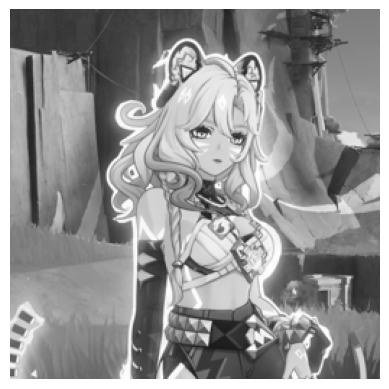

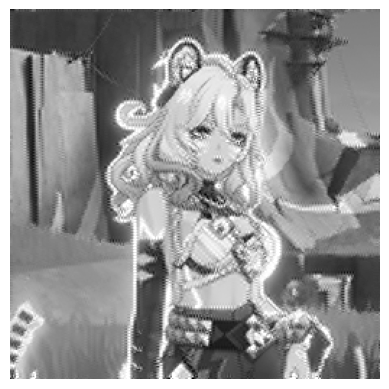

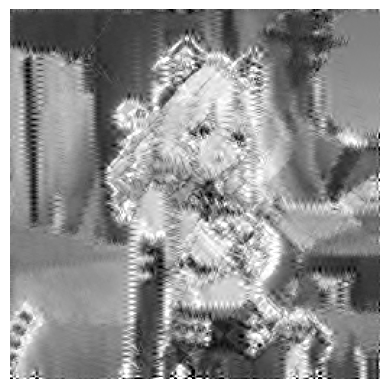

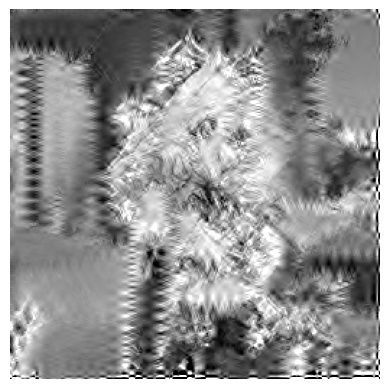

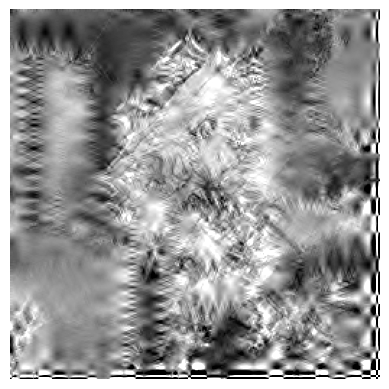

Средняя дисперсия:  25816.636854091306


In [60]:
show_matrix_as_image(img)

loc_res = wavelet97_2d(imgf)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL1 = loc_res[:new_shir, :new_vi]
LH1 = loc_res[new_shir:, :new_vi]
HL1 = loc_res[:new_shir, new_vi:]
HH1 = loc_res[new_shir:, new_vi:]

inv1 = wavelet97_2d_back(LL1, LH1, HL1, HH1)
show_matrix_as_image(inv1)


loc_res = wavelet97_2d(LL1)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL2 = loc_res[:new_shir, :new_vi]
LH2 = loc_res[new_shir:, :new_vi]
HL2 = loc_res[:new_shir, new_vi:]
HH2 = loc_res[new_shir:, new_vi:]

inv2 = wavelet97_2d_back(LL2, LH2, HL2, HH2)
inv1 = wavelet97_2d_back(inv2, LH1, HL1, HH1)
show_matrix_as_image(inv1)


loc_res = wavelet97_2d(LL2)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL3 = loc_res[:new_shir, :new_vi]
LH3 = loc_res[new_shir:, :new_vi]
HL3 = loc_res[:new_shir, new_vi:]
HH3 = loc_res[new_shir:, new_vi:]

inv3 = wavelet97_2d_back(LL3, LH3, HL3, HH3)
inv2 = wavelet97_2d_back(inv3, LH2, HL2, HH2)
inv1 = wavelet97_2d_back(inv2, LH1, HL1, HH1)
show_matrix_as_image(inv1)


loc_res = wavelet97_2d(LL3)
new_shir = loc_res.shape[1] // 2   #ширина матрицы
new_vi = loc_res.shape[0] // 2       #высота матрицы
LL4 = loc_res[:new_shir, :new_vi]
LH4 = loc_res[new_shir:, :new_vi]
HL4 = loc_res[:new_shir, new_vi:]
HH4 = loc_res[new_shir:, new_vi:]

LL3 = wavelet97_2d_back(LL4, LH4, HL4, HH4)
LL2 = wavelet97_2d_back(LL3, LH3, HL3, HH3)
LL1 = wavelet97_2d_back(LL2, LH2, HL2, HH2)
LL = wavelet97_2d_back(LL1, LH1, HL1, HH1)

show_matrix_as_image(LL)

disp = 0
for i in range(0, 256):
    for j in range(0, 256):
        disp = disp + ((imgf[i][j] - LL[i][j]) / 256) ** 2
print("Средняя дисперсия: ", disp)